In [1]:
import os
import struct

import pandas as pd
import numpy as np

In [2]:
workdir_path = os.getcwd()
print(workdir_path)

c:\Users\Andry\Desktop\temp\Material_props


- 0...1 - хз пока  (вроде везде нули - 0000 0000) для выравнивания?  
- 2...13 -   
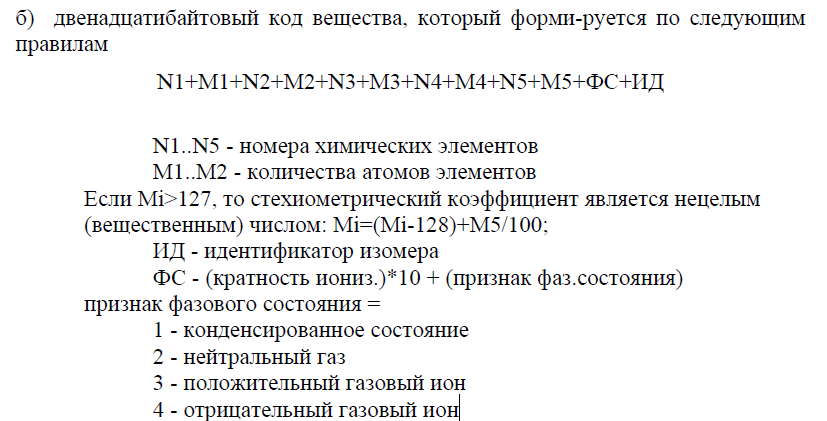  
для O -> 0801 0000 0000 0000 0000 0200
- 14...16 - хз пока  
- 17... .. - формула вещества  
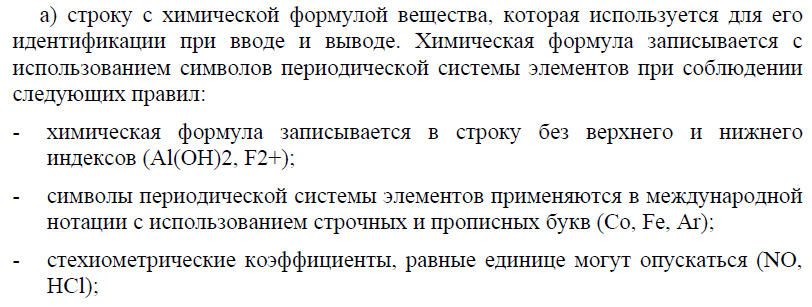  
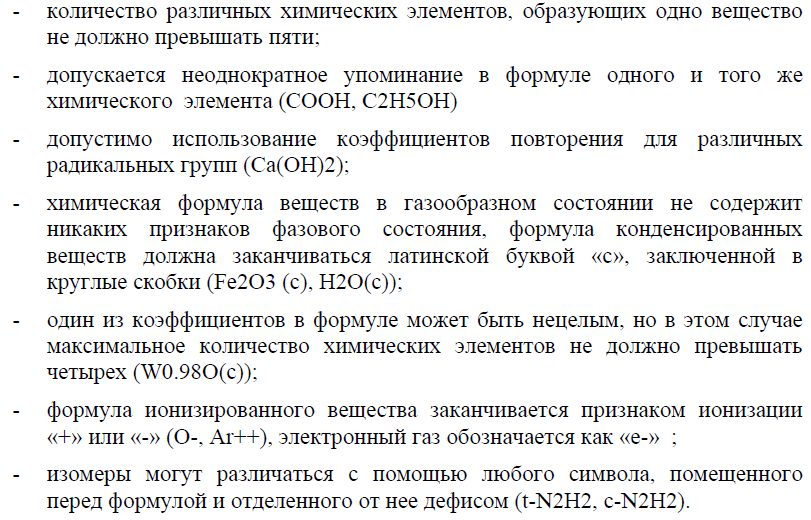  


#### Working part

In [3]:
df_PToE = pd.read_csv(os.path.join(workdir_path, 'Terra', 'Periodic_Table_of_Elements.csv'), sep=',')

In [20]:
def parse_substance_code_from_bytes(byte_data: bytes):
    if len(byte_data) < 12:
        raise ValueError(f"Нужно минимум 12 байт, получено: {len(byte_data)}")

    elements = {}
    for i in range(0, 10, 2):
        idx = i // 2 + 1
        el_num = byte_data[i]
        el_count = byte_data[i+1]
        if el_count > 127:
            el_count = (el_count - 128) + byte_data[9] / 100  # M5 — всегда последний коэффициент
        elements[f'M{idx}'] = el_num
        elements[f'N{idx}'] = el_count

    fs = byte_data[10]
    ionization = fs // 10
    phase_code = fs % 10
    phase_map = {
        1: 1, # condensed gas
        2: 2, # neutral gas
        3: 3, # positive gas
        4: 4 # negative gas
    }

    isomer_id = byte_data[11]

    result = {
        **elements,
        "ionization": ionization,
        "phase": phase_map.get(phase_code, "none"),  # можно позже маппить в строки
        "isomer_id": isomer_id
    }

    return result



with open(os.path.join(workdir_path, 'Terra', 'terra.props'), 'rb') as f:
    data = f.read()

block_size = 64
num_elements = 2613
a = []

df_1 = pd.DataFrame(columns=[
    'N1', 'M1', 'N2', 'M2', 'N3', 'M3', 'N4', 'M4', 'N5', 'M5', 'ionization', 'phase', 'isomer_id',
    'Formula',
    'Empty_1', 'Enthalpy', 'Molar_mass', 'Sigma', 
    'Epsilon/k', 'Delta', 'Pol_num', 'Group_num', 'Num_in_group'
])

all_data = []

for i in range(num_elements):
    offset = i * block_size
    block = data[offset:offset + block_size]

    # Парсим состав и свойства
    parsed = parse_substance_code_from_bytes(block[4:16])
    phase = parsed['phase']


    a = [*parse_substance_code_from_bytes(block[4:16]).values()]
    formula = ''

    for e, k in zip(a[:10], range(10)):
        if k % 2 == 0 and e != 0:
            formula += df_PToE.loc[df_PToE['AtomicNumber'] == e, 'Symbol'].values[0]
        if k % 2 and (e == 1 or e == 0):
            continue
        elif k % 2:
            formula += str(e)
    if phase == 1:
        formula += '(c)'
    elif phase == 3:
        formula += '+' * parsed['ionization']
    elif phase == 4:
        formula += '-' * parsed['ionization']



    # Извлекаем и обрабатываем имя элемента
    # raw_element = block[16:32][1:].split(b'\x00')[0].decode('utf-8', errors='replace')
    # cleaned_element = raw_element.replace('(', '').replace(')', '').replace('c', '')
    # if phase == "condensed_g (1)":
        # cleaned_element += '(c)'

    # Сбор строки

    all_data.append([
        *parsed.values(),
        formula,
        *struct.unpack('<ffff', block[32:48]),
        *struct.unpack('<ff', block[48:56]),
        *struct.unpack('<i', block[56:60]),
        [*struct.unpack('<i', block[60:64])][0] // 1000,
        [*struct.unpack('<i', block[60:64])][0] % 1000
        ])

    # df_1.loc[len(df_1)] = [
        # *parsed.values(),
        # formula,
        # *struct.unpack('<ffff', block[32:48]),
        # *struct.unpack('<ff', block[48:56]),
        # *struct.unpack('<i', block[56:60]),
        # [*struct.unpack('<i', block[60:64])][0] // 1000,
        # [*struct.unpack('<i', block[60:64])][0] % 1000
    # ]

df_1 = pd.DataFrame(all_data, columns=df_1.columns)

df_1.loc[0:1, 'Pol_num'] =  [1, 2]

df_1.to_csv(os.path.join(workdir_path, 'Terra', 'Elements.csv'), index=False)

In [21]:
sorted_df_1 = df_1.sort_values(by=['Group_num', 'Num_in_group'], ascending=True)

sorted_df_1['Link_to_pol'] = sorted_df_1['Pol_num'].cumsum().shift(1, fill_value=0)

sorted_df_1['Pol_in_group'] = sorted_df_1.groupby('Group_num')['Pol_num'].transform('sum')

sorted_df_1.to_csv(os.path.join(workdir_path, 'Terra', 'Elements_sorted.csv'), index=False)

In [6]:
with open(os.path.join(workdir_path, 'Terra', 'terra.props'), 'rb') as f:
    f.seek(0x00029800)
    data_pol = f.read()

block_size = 36
group_size = 2048
num_polynomials = df_1['Pol_num'].sum()

cumulative_pol_counts = [0] + list(sorted_df_1.groupby('Group_num')['Pol_in_group'].max().cumsum())[:-1]

df_2 = pd.DataFrame(columns=[
    'pol_num', 'Tmin', 'Tmax', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7'
])

num_groups = df_1['Group_num'].nunique()
num_pols_in_groups = [*sorted_df_1.groupby('Group_num')['Pol_in_group'].max()]

all_data = []
for i, size in enumerate(num_pols_in_groups):
    start_pol_num = cumulative_pol_counts[i]
    group_offset = i * group_size
    group = data_pol[group_offset:group_offset + group_size]
    for k in range(size):
        offset = k * block_size
        block = group[offset:offset + block_size]
        all_data.append([start_pol_num + k, *struct.unpack('<fffffffff', block[0:36])])

df_2 = pd.DataFrame(all_data, columns=df_2.columns)

df_2.to_csv(os.path.join(workdir_path, 'Terra', 'pol_coef.csv'), index=False)

#### Test part

In [89]:
def parse_substance_code(hex_str):

    bytes_data = bytes.fromhex(hex_str[:24])  # только 12 байт

    result = {}
    for i in range(5):
        el_idx = i * 2
        element_id = bytes_data[el_idx]
        atom_count = bytes_data[el_idx + 1]
        if atom_count > 127:
            atom_count = (atom_count - 128) + bytes_data[9] / 100  # M5 – последний коэффициент
        result[f'N{i+1}'] = element_id
        result[f'M{i+1}'] = atom_count

    fs = bytes_data[10]
    result["ionization"] = fs // 10
    phase_code = fs % 10
    phase_map = {
        1: "condensed_g",
        2: "neutral_g",
        3: "positive_g",
        4: "negative_g"
    }
    result["phase"] = phase_map.get(phase_code, "неизвестно")
    result["isomer_id"] = bytes_data[11]

    return result

codes = [
    "010100000000000000000200"
]

data = [parse_substance_code(code) for code in codes]
df = pd.DataFrame(data)
df

,N1,M1,N2,M2,N3,M3,N4,M4,N5,M5,ionization,phase,isomer_id
0,1,1,0,0,0,0,0,0,0,0,0,neutral_g,0


In [ ]:
with open(os.path.join(workdir_path, 'Terra', 'terra.props'), 'rb') as f:
    data = f.read()

value = struct.unpack('<f', bytes.fromhex('33 33 43 40'))[0]  # '<f' - little-endian float32
value

print(data[4:16].hex(' '))
value = struct.unpack('12B', data[4:16])
value

raw = data[16:32][1:]
if raw[0] < 32:  # если это управляющий символ (например, 0x01)
    raw = raw[1:]
formula = raw.split(b'\x00')[0].decode('utf-8', errors='replace')
print(formula)

# raw_formula = data[17:18]  # возьмём первый возможный блок
# formula = raw_formula.split(b'\x00')[0].decode('utf-8', errors='replace')  # если C-style
# print(f"Формула: {formula}")


bytes_data = bytes.fromhex('52 c3 6c 48')
value_float = struct.unpack('<f', bytes_data)[0]  # '<f' = little-endian float32
print(value_float) 



with open(os.path.join(workdir_path, 'Terra', 'terra.props'), 'rb') as f:
    f.seek(0x00029800)
    data_pol = f.read()

i = 0

print(data_pol[i:i+16].hex(' '))

p1, p2, p3, p4 = struct.unpack('<ffff', data_pol[i:i+16])  # '<f' = little-endian float32
print(f'{p1}\n{p2}\n{p3}\n{p4}')

In [143]:
value = struct.unpack('<f', bytes.fromhex('2a b4 8d 43'))[0]  # '<f' - little-endian float32
value

283.40753173828125

In [ ]:
i=0
# list(range(0, 12)) + 
sorted_df_1.iloc[i:i+20, list(range(10, 21))] #+ list(range(16, 17)) + list(range(20, 25))

,M5,Ionization,Phase,Isomer_id,Formula,Enthalpy,Molar_mass,Sigma,Epsilon/k,Delta,Pol_num
0,0,0,2,0,O,2.424453e+05,15.999400,3.050000,107.000000,0.000000,1
1,0,0,2,0,O2,-8.682010e+03,31.998800,3.470000,107.000000,0.000000,2
2,0,0,2,0,H,2.118002e+05,1.007900,2.710000,37.000000,0.000000,1
3,0,0,2,0,H2,-8.468010e+03,2.015800,2.930000,34.099998,0.000000,2
4,0,0,2,0,OH,3.052203e+04,17.007299,3.150000,80.000000,0.000000,2
5,0,0,2,0,HO2,-3.160003e+02,33.006699,3.070000,168.000000,0.000000,1
6,0,0,2,0,H2O,-2.517223e+05,18.015200,2.830000,454.599976,1.336537,1
7,0,0,1,0,H2O2(c),-2.107292e+05,34.014599,0.000023,0.000000,0.000000,1
8,0,0,2,0,H2O2,-1.470382e+05,34.014599,4.200000,289.000000,0.717776,2
10,0,0,2,0,F2,-8.825010e+03,37.996799,3.360000,113.000000,0.000000,1


In [42]:
sorted_df_1['Index_key'] = range(0, len(sorted_df_1))

In [69]:
i=0
df_2.iloc[i:i+20, :]

,Pol_index,Index_key,Tmin,Tmax,f1,f2,f3,f4,f5,f6,f7
0,0,0,298.149963,6000.0,214.239532,20.972309,0.000453,-0.079173,-1.185662,1.306771,0.000000
1,1,1,298.149963,2000.0,254.806351,21.977114,0.000730,-0.170708,114.092308,-211.010681,216.918533
2,2,1,2000.000000,6000.0,288.231201,37.776737,-0.048113,1.474844,5.573169,0.000000,0.000000
3,3,2,298.149963,6000.0,166.835831,20.785988,0.000000,0.000028,0.000000,0.000000,0.000000
4,4,3,298.149963,3000.0,203.369186,28.874722,0.000033,0.008711,-4.820117,50.743935,-50.972885
5,5,3,3000.000000,6000.0,205.603302,36.061832,-0.107923,2.319341,5.535447,0.000000,0.000000
6,6,4,298.149963,3000.0,251.328018,26.854628,0.000974,-0.133216,14.417934,20.868921,-30.659939
7,7,4,3000.000000,6000.0,261.751831,38.050903,-0.117485,2.565728,2.503948,0.000000,0.000000
8,8,5,298.149963,6000.0,309.425201,34.896622,-0.002126,0.259253,79.297256,-53.915428,18.301249
9,9,6,298.149963,6000.0,248.138336,25.331301,0.001241,-0.235413,97.464859,-62.643478,22.568386


In [68]:
df_2.rename(columns={'pol_num': 'Pol_index'}, inplace=True)


In [ ]:
sorted_df_1 = sorted_df_1.drop(columns=['Group_num', 'Num_in_group', 'Link_to_pol', 'Pol_in_group', 'Empty_1'])

In [52]:
column_to_move = sorted_df_1.pop('Index_key')  

# Шаг 2: Вставляем её в начало (позиция 0)
sorted_df_1.insert(0, 'Index_key', column_to_move) 

In [50]:
column_to_move = df_2.pop('Index_key')  

# Шаг 2: Вставляем её в начало (позиция 0)
df_2.insert(1, 'Index_key', column_to_move) 

In [70]:
df_2.to_csv(os.path.join(workdir_path, 'Terra', 'Pol_coef_for_db.csv'), index=False)

In [71]:
sorted_df_1.to_csv(os.path.join(workdir_path, 'Terra', 'Elements_for_db.csv'), index=False)

In [ ]:
[*sorted_df_1['Index_key'].repeat(sorted_df_1['Pol_num'])]

In [44]:
df_2['Index_key'] = [*sorted_df_1['Index_key'].repeat(sorted_df_1['Pol_num'])]

In [38]:
i=40
df_PToE.iloc[i:i+20, :4]

,AtomicNumber,Element,Symbol,AtomicMass
40,41,Niobium,Nb,92.906
41,42,Molybdenum,Mo,95.960
42,43,Technetium,Tc,98.000
43,44,Ruthenium,Ru,101.070
44,45,Rhodium,Rh,102.906
45,46,Palladium,Pd,106.420
46,47,Silver,Ag,107.868
47,48,Cadmium,Cd,112.411
48,49,Indium,In,114.818
49,50,Tin,Sn,118.710
